# Data Preprocessing & Exploratory Data Analysis (EDA)
**Proyek Skripsi:** Klasifikasi Jenis Obat Tablet Menggunakan Convolutional Neural Network (CNN)

## Tujuan Notebook Ini:
1. Mengekstrak dataset mentah (`raw.zip`).
2. Melakukan Exploratory Data Analysis (EDA) untuk memvalidasi jumlah dan distribusi kelas.
3. Menerapkan teknik *padding* dan *resizing* (224x224 piksel) agar geometri citra obat (bulat/lonjong) tidak rusak (distorsi).
4. Menyimpan citra yang telah diproses ke dalam folder `baseline_dataset` yang akan digunakan secara seragam pada Skenario A, B, dan C.

*Catatan: Normalisasi piksel (0-1) akan diaplikasikan secara dinamis pada saat proses training (menggunakan `ImageDataGenerator` atau `Rescaling Layer`) untuk menghemat kapasitas memori disk.*

In [1]:
# Import library standar industri
import os
import zipfile
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Menghubungkan Google Colab dengan Google Drive
drive.mount('/content/drive')

print("✅ Library berhasil diimpor dan Google Drive telah terhubung.")

Mounted at /content/drive
✅ Library berhasil diimpor dan Google Drive telah terhubung.


## 1. Konfigurasi Parameter & Direktori
Mendefinisikan variabel global, jalur (*path*) direktori, dan 7 kelas target obat yang telah disetujui untuk penelitian.


In [2]:
# ==========================================
# KONFIGURASI DIREKTORI & HYPERPARAMETER
# ==========================================

# Path utama di Google Drive Anda
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/SKRIPSI-ALWI-COLAB'

# Mendefinisikan path untuk setiap tahap data
ZIP_PATH = os.path.join(BASE_DIR, 'raw.zip') # Pastikan file ini ada di GDrive Anda
RAW_DIR = os.path.join(BASE_DIR, 'data', 'raw')
BASELINE_DIR = os.path.join(BASE_DIR, 'data', 'baseline_dataset')

# 7 Kelas Obat (Sesuai Konfirmasi Dosen)
TARGET_CLASSES = [
    "cataflam_50_mg",
    "cetirizin_10_mg",
    "pantoprazol_sandoz_40_mg",
    "c_vitamin_teva_500_mg",
    "aspirin_ultra_500_mg",
    "algoflex_forte_dolo_400_mg",
    "merckformin_xr_1000_mg"
]

# Dimensi input standar untuk CNN (terutama EfficientNet)
IMG_SIZE = (224, 224)

# Membuat struktur direktori utama jika belum ada
for directory in [RAW_DIR, BASELINE_DIR]:
    os.makedirs(directory, exist_ok=True)

print("✅ Konfigurasi dan struktur direktori siap.")

✅ Konfigurasi dan struktur direktori siap.


## 2. Ekstraksi Dataset Mentah
Membongkar file `raw.zip` ke dalam folder `raw`. Proses ini hanya akan berjalan jika folder `raw` masih kosong untuk menghemat waktu pada proses *run* berikutnya.


In [3]:
def extract_dataset(zip_path, extract_to):
    """
    Mengekstrak file ZIP dataset ke direktori tujuan.

    Args:
        zip_path (str): Lokasi file ZIP di Google Drive.
        extract_to (str): Folder tujuan ekstraksi.
    """
    # Cek apakah folder raw sudah memiliki isi (menghindari ekstrak berulang)
    if not os.path.exists(zip_path):
        print(f"❌ ERROR: File {zip_path} tidak ditemukan! Pastikan Anda sudah menguploadnya.")
        return

    if len(os.listdir(extract_to)) == 0:
        print("Mengekstrak dataset... Mohon tunggu.")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print("✅ Ekstraksi selesai!")
    else:
        print("✅ Dataset sudah terekstrak sebelumnya. Melanjutkan ke tahap berikutnya.")

# Eksekusi fungsi
extract_dataset(ZIP_PATH, RAW_DIR)

✅ Dataset sudah terekstrak sebelumnya. Melanjutkan ke tahap berikutnya.


## 3. Exploratory Data Analysis (EDA) - Distribusi Dataset
Menghitung jumlah citra pada setiap kelas di dalam folder `train`, `valid`, dan `test` untuk memastikan data seimbang (*balanced*) dan tidak ada *file* yang hilang.

📊 Laporan Distribusi Dataset:

--- Bagian: TRAIN ---
cataflam_50_mg: 28 gambar
cetirizin_10_mg: 28 gambar
pantoprazol_sandoz_40_mg: 28 gambar
c_vitamin_teva_500_mg: 28 gambar
aspirin_ultra_500_mg: 28 gambar
algoflex_forte_dolo_400_mg: 28 gambar
merckformin_xr_1000_mg: 28 gambar

--- Bagian: VAL ---
cataflam_50_mg: 6 gambar
cetirizin_10_mg: 6 gambar
pantoprazol_sandoz_40_mg: 6 gambar
c_vitamin_teva_500_mg: 6 gambar
aspirin_ultra_500_mg: 6 gambar
algoflex_forte_dolo_400_mg: 6 gambar
merckformin_xr_1000_mg: 6 gambar

--- Bagian: TEST ---
cataflam_50_mg: 6 gambar
cetirizin_10_mg: 6 gambar
pantoprazol_sandoz_40_mg: 6 gambar
c_vitamin_teva_500_mg: 6 gambar
aspirin_ultra_500_mg: 6 gambar
algoflex_forte_dolo_400_mg: 6 gambar
merckformin_xr_1000_mg: 6 gambar


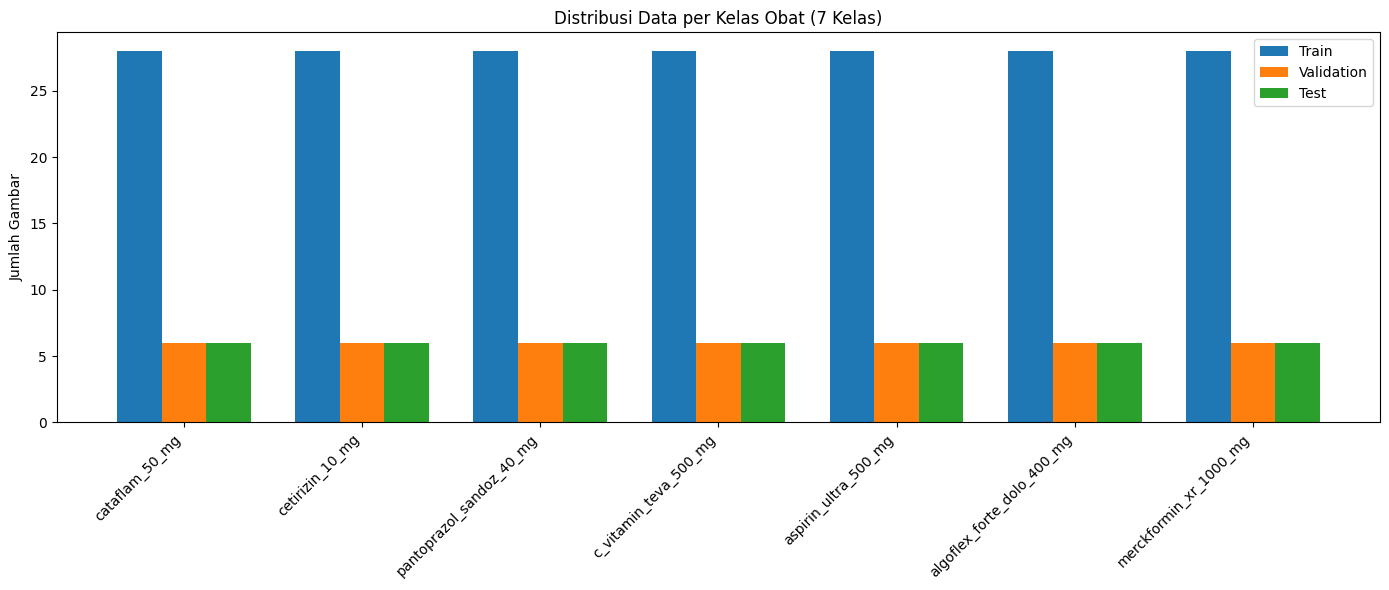

In [4]:
def plot_dataset_distribution(raw_dir, classes):
    """
    Menghitung dan memvisualisasikan jumlah citra per kelas dalam bentuk Bar Chart.
    Otomatis mendeteksi masalah double-folder dan perbedaan nama folder validasi.
    """
    # Deteksi jika ada folder 'raw' di dalam 'raw'
    actual_raw = os.path.join(raw_dir, 'raw') if os.path.exists(os.path.join(raw_dir, 'raw')) else raw_dir

    # Deteksi nama folder validasi (val atau valid)
    val_name = 'val' if os.path.exists(os.path.join(actual_raw, 'val')) else 'valid'
    splits = ['train', val_name, 'test']

    distribution = {split: [] for split in splits}
    print("📊 Laporan Distribusi Dataset:")

    for split in splits:
        print(f"\n--- Bagian: {split.upper()} ---")
        for cls in classes:
            class_dir = os.path.join(actual_raw, split, cls)
            if os.path.exists(class_dir):
                num_images = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            else:
                num_images = 0

            distribution[split].append(num_images)
            print(f"{cls}: {num_images} gambar")

    # Visualisasi
    x = np.arange(len(classes))
    width = 0.25

    fig, ax = plt.subplots(figsize=(14, 6))
    rects1 = ax.bar(x - width, distribution['train'], width, label='Train')
    rects2 = ax.bar(x, distribution[val_name], width, label='Validation')
    rects3 = ax.bar(x + width, distribution['test'], width, label='Test')

    ax.set_ylabel('Jumlah Gambar')
    ax.set_title('Distribusi Data per Kelas Obat (7 Kelas)')
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, 'dataset_distribution.png'))
    plt.show()

# Eksekusi visualisasi
plot_dataset_distribution(RAW_DIR, TARGET_CLASSES)

## 4. Preprocessing Logic (Fungsi Inti)
Membuat fungsi untuk mengubah ukuran gambar menjadi **224x224 piksel**.
Untuk mempertahankan *Aspect Ratio* (rasio aspek) agar bentuk asli obat tidak mendistorsi (gepeng/memanjang), kita menerapkan teknik penambahan tepi hitam (*padding*).

In [5]:
def pad_and_resize(image, target_size=(224, 224)):
    """
    Melakukan preprocessing citra dengan mempertahankan aspect ratio.

    Proses:
    - Menghitung rasio skala berdasarkan sisi terpanjang citra asli.
    - Melakukan resize proporsional.
    - Menambahkan padding (warna hitam) pada sisi yang pendek hingga mencapai target_size.

    Args:
        image (numpy.ndarray): Matriks citra dari OpenCV.
        target_size (tuple): Ukuran output citra (default: 224x224).

    Returns:
        numpy.ndarray: Citra yang telah diproses.
    """
    old_size = image.shape[:2] # (height, width)
    ratio = float(target_size[0]) / max(old_size)
    new_size = tuple([int(x * ratio) for x in old_size])

    # Resize proporsional
    image_resized = cv2.resize(image, (new_size[1], new_size[0]))

    # Hitung padding yang dibutuhkan
    delta_w = target_size[1] - new_size[1]
    delta_h = target_size[0] - new_size[0]
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)

    # Terapkan padding warna hitam RGB(0,0,0)
    color = [0, 0, 0]
    new_image = cv2.copyMakeBorder(image_resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)

    return new_image

## 5. Eksekusi Preprocessing Dataset
Mengaplikasikan fungsi `pad_and_resize` ke seluruh dataset (Train, Valid, Test) pada 7 kelas target. Hasil yang sudah bersih dan terstandarisasi akan disimpan ke dalam direktori `baseline_dataset`.

In [6]:
def process_all_images(src_dir, dst_dir, classes):
    """
    Memproses seluruh citra dari direktori raw dan menyimpannya ke direktori baseline.
    """
    # Deteksi folder 'raw' ganda
    actual_src = os.path.join(src_dir, 'raw') if os.path.exists(os.path.join(src_dir, 'raw')) else src_dir

    # Deteksi nama folder validasi
    val_name = 'val' if os.path.exists(os.path.join(actual_src, 'val')) else 'valid'
    splits_src = ['train', val_name, 'test']
    splits_dst = ['train', 'valid', 'test'] # Tetap gunakan 'valid' untuk output agar konsisten

    for src_split, dst_split in zip(splits_src, splits_dst):
        print(f"\n🔄 Memproses kumpulan data: {src_split.upper()}")
        for cls in classes:
            src_class_path = os.path.join(actual_src, src_split, cls)
            dst_class_path = os.path.join(dst_dir, dst_split, cls)

            os.makedirs(dst_class_path, exist_ok=True)

            if not os.path.exists(src_class_path):
                continue

            images = [f for f in os.listdir(src_class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            processed_count = 0

            for img_name in images:
                src_img_path = os.path.join(src_class_path, img_name)
                dst_img_path = os.path.join(dst_class_path, img_name)

                if os.path.exists(dst_img_path):
                    processed_count += 1
                    continue

                img = cv2.imread(src_img_path)
                if img is None:
                    continue

                img_processed = pad_and_resize(img, IMG_SIZE)
                cv2.imwrite(dst_img_path, img_processed)
                processed_count += 1

            print(f"   [{cls}] Selesai memproses {processed_count} gambar.")

process_all_images(RAW_DIR, BASELINE_DIR, TARGET_CLASSES)
print("\n✅ SELURUH DATASET TELAH BERHASIL DIPROSES DAN DISIMPAN KE BASELINE_DATASET!")


🔄 Memproses kumpulan data: TRAIN
   [cataflam_50_mg] Selesai memproses 28 gambar.
   [cetirizin_10_mg] Selesai memproses 28 gambar.
   [pantoprazol_sandoz_40_mg] Selesai memproses 28 gambar.
   [c_vitamin_teva_500_mg] Selesai memproses 28 gambar.
   [aspirin_ultra_500_mg] Selesai memproses 28 gambar.
   [algoflex_forte_dolo_400_mg] Selesai memproses 28 gambar.
   [merckformin_xr_1000_mg] Selesai memproses 28 gambar.

🔄 Memproses kumpulan data: VAL
   [cataflam_50_mg] Selesai memproses 6 gambar.
   [cetirizin_10_mg] Selesai memproses 6 gambar.
   [pantoprazol_sandoz_40_mg] Selesai memproses 6 gambar.
   [c_vitamin_teva_500_mg] Selesai memproses 6 gambar.
   [aspirin_ultra_500_mg] Selesai memproses 6 gambar.
   [algoflex_forte_dolo_400_mg] Selesai memproses 6 gambar.
   [merckformin_xr_1000_mg] Selesai memproses 6 gambar.

🔄 Memproses kumpulan data: TEST
   [cataflam_50_mg] Selesai memproses 6 gambar.
   [cetirizin_10_mg] Selesai memproses 6 gambar.
   [pantoprazol_sandoz_40_mg] Selesai

## 6. Visualisasi Hasil Preprocessing
Menampilkan perbandingan gambar asli (Mentah) vs gambar setelah diproses (*Padding* & *Resize*) untuk validasi visual bahwa bentuk tablet obat tidak mengalami distorsi.

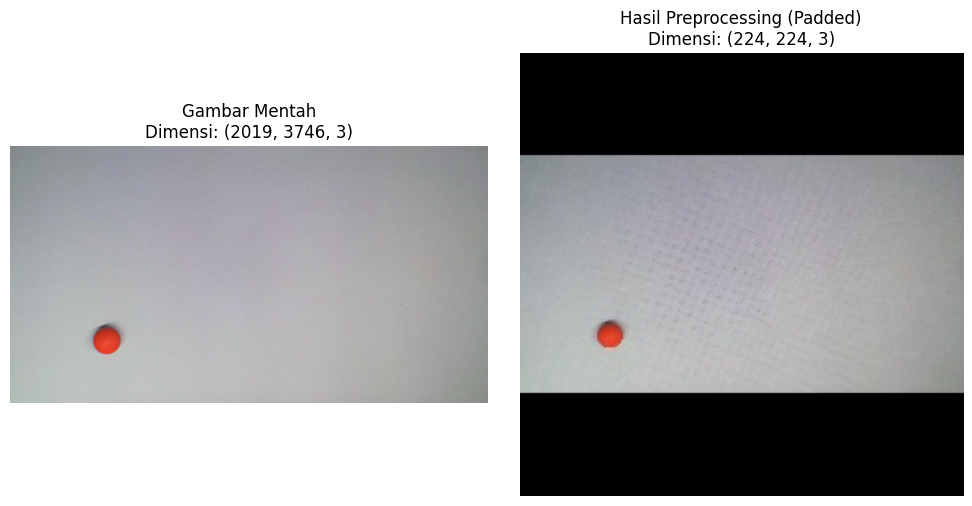

In [14]:
def visualize_preprocessing_result(cls_name='cataflam_50_mg'):
    """
    Menampilkan perbandingan visual citra mentah dan hasil preprocessing.
    """
    # Deteksi folder 'raw' ganda
    actual_raw = os.path.join(RAW_DIR, 'raw') if os.path.exists(os.path.join(RAW_DIR, 'raw')) else RAW_DIR

    src_folder = os.path.join(actual_raw, 'train', cls_name)
    dst_folder = os.path.join(BASELINE_DIR, 'train', cls_name)

    # PERBAIKAN: Menggunakan os.listdir, BUKAN os.path.listdir
    if os.path.exists(src_folder) and len(os.listdir(src_folder)) > 0:
        sample_img = os.listdir(src_folder)[0]

        # Load citra Mentah
        img_raw = cv2.imread(os.path.join(src_folder, sample_img))
        img_raw = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB) # Convert BGR ke RGB untuk Matplotlib

        # Load citra Hasil Preprocessing
        img_proc = cv2.imread(os.path.join(dst_folder, sample_img))
        img_proc = cv2.cvtColor(img_proc, cv2.COLOR_BGR2RGB)

        # Plotting
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].imshow(img_raw)
        axes[0].set_title(f"Gambar Mentah\nDimensi: {img_raw.shape}")
        axes[0].axis('off')

        axes[1].imshow(img_proc)
        axes[1].set_title(f"Hasil Preprocessing (Padded)\nDimensi: {img_proc.shape}")
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("❌ Contoh gambar tidak ditemukan. Periksa kembali nama kelas atau path direktori.")

# Uji coba visualisasi pada kelas Cataflam
visualize_preprocessing_result('cataflam_50_mg')

## ✅ KESIMPULAN FASE 2
Dataset `baseline_dataset` kini telah tersusun rapi, bersih, dan seragam (224x224 piksel). Dataset inilah yang akan menjadi *"Single Source of Truth"* (sumber data mutlak) untuk:
- `02_Scenario_A.ipynb`
- `03_Scenario_B.ipynb`
- `04_Scenario_C.ipynb`

*Tugas Notebook 01 selesai. Anda dapat menutup notebook ini dan beralih ke Notebook Skenario A.*